# ST-GCN - cosine-schedule isolated ablation

The earlier ablation isolated tcn_dropout / label_smoothing / weight_decay individually, but on **StepLR**, where training freezes by epoch 30 regardless. Stripping tcn_dropout out of the cosine run based on that ablation made things *worse* across every metric - the model hit 100% train accuracy by epoch 50 with nothing left to stop it. Cosine keeps training genuinely alive the whole run, so its regularization needs are different, and the StepLR ablation doesn't transfer cleanly.

This redoes the same isolation, properly this time - cosine as the fixed schedule throughout, not StepLR. Also **patience dropped to 10** (from 20): the last cosine run never actually triggered early stopping, it ran the full 60-epoch budget oscillating on noise after val_top1 peaked at epoch 40 - patience=20 wasn't catching anything real.

Four configs, cosine schedule fixed, augmentation fixed (advanced, p=0.8), one variable changed per run:
1. **cosine_none** - no extra regularization at all. Never actually tested in isolation - every cosine run so far had some combination of extras already stacked in.
2. **cosine_weight_decay** - 1e-3, the single strongest isolated result under StepLR
3. **cosine_label_smoothing** - 0.1
4. **cosine_tcn_dropout** - 0.15, retested here specifically because its effect may flip under a schedule that doesn't self-limit training time the way StepLR does

### determinism - before torch touches CUDA

In [1]:
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import sys
import json
import functools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, top_k_accuracy_score

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

sys.path.insert(0, "/workspace/badminton-honours-project")
import dataset as ds

import mmaction.models  # noqa: F401
from mmaction.utils import register_all_modules
register_all_modules()
from mmaction.registry import MODELS

from clearml import Task

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda:0


### paths

In [2]:
OUT_ROOT = "/workspace/outputs/stgcn_cosine_ablation"
CKPT_ROOT = "/workspace/checkpoints/stgcn_cosine_ablation"
os.makedirs(OUT_ROOT, exist_ok=True)
os.makedirs(CKPT_ROOT, exist_ok=True)


### data - advanced augmentation, p=0.8 (matches the best-top1 setup)

In [3]:
manifest = ds.load_filtered_manifest(
    "/workspace/data/split_manifest.csv",
    "/workspace/data/extraction_log.csv",
)

class_names = sorted(manifest["class_name"].unique())
class_to_id = {name: i for i, name in enumerate(class_names)}
num_classes = len(class_names)

train_manifest = manifest[manifest["split"] == "train"].reset_index(drop=True)
val_manifest = manifest[manifest["split"] == "val"].reset_index(drop=True)
test_manifest = manifest[manifest["split"] == "test"].reset_index(drop=True)

KEYPOINTS_ROOT = "/workspace/data/keypoints_smoothed"

ds.AUGMENTATION_POLICIES["advanced_p08"] = [
    functools.partial(fn, p=0.8) for fn in ds.ADVANCED_AUGMENTATIONS
]

train_ds = ds.BadmintonPoseDataset(train_manifest, KEYPOINTS_ROOT, class_to_id, augmentation_policy="advanced_p08")
val_ds = ds.BadmintonPoseDataset(val_manifest, KEYPOINTS_ROOT, class_to_id)
test_ds = ds.BadmintonPoseDataset(test_manifest, KEYPOINTS_ROOT, class_to_id)

balanced_sampler = ds.build_class_balanced_sampler(train_manifest, target_per_class=500, seed=42)

val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

print(f"{num_classes} classes, train {len(train_manifest)}, val {len(val_ds)}, test {len(test_ds)}")


dropped 4 manually-excluded clips from the manifest (7814 remain)
18 classes, train 6251, val 781, test 782


### batch -> ST-GCN input, metrics - unchanged

In [4]:
def batch_to_stgcn_input(batch):
    kp = batch["keypoints"].float()
    x = kp.unsqueeze(1).unsqueeze(1)
    return x


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    for batch in loader:
        x = batch_to_stgcn_input(batch).to(device)
        y = batch["label"].to(device)
        logits = model(x, mode="tensor", stage="head")
        probs = torch.softmax(logits, dim=1)
        all_labels.append(y.cpu().numpy())
        all_preds.append(probs.argmax(dim=1).cpu().numpy())
        all_probs.append(probs.cpu().numpy())
    labels = np.concatenate(all_labels)
    preds = np.concatenate(all_preds)
    probs = np.concatenate(all_probs)
    return {
        "top1": accuracy_score(labels, preds),
        "top5": top_k_accuracy_score(labels, probs, k=5, labels=list(range(num_classes))),
        "mca": balanced_accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "labels": labels, "preds": preds,
    }


### the reusable training function

Cosine schedule and patience=10 fixed for every config this time - only `tcn_dropout`, `label_smoothing`, and `weight_decay` vary between calls.

In [5]:
def train_one_config(config_name, seed=42, tcn_dropout=0.0, label_smoothing=0.0,
                      weight_decay=5e-4, num_epochs=60, patience=10, batch_size=16, lr=0.01):
    torch.manual_seed(seed)
    np.random.seed(seed)

    model_cfg = dict(
        type="RecognizerGCN",
        backbone=dict(
            type="STGCN",
            graph_cfg=dict(layout="coco", mode="stgcn_spatial"),
            in_channels=3, base_channels=64, ch_ratio=2,
            num_stages=9, inflate_stages=[4, 7], down_stages=[4, 7],
            tcn_dropout=tcn_dropout,
        ),
        cls_head=dict(type="GCNHead", num_classes=num_classes, in_channels=256,
                      loss_cls=dict(type="CrossEntropyLoss")),
    )
    model = MODELS.build(model_cfg).to(device)

    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=balanced_sampler,
                               num_workers=4, pin_memory=True, persistent_workers=True)

    task = Task.init(project_name="BadmintonPoseAnalysis", task_name=f"stgcn_cosine_ablation_{config_name}", reuse_last_task_id=False)
    logger = task.get_logger()
    task.connect({
        "config_name": config_name, "seed": seed, "tcn_dropout": tcn_dropout,
        "label_smoothing": label_smoothing, "weight_decay": weight_decay,
        "schedule": "cosine", "patience": patience, "lr": lr, "batch_size": batch_size,
    })

    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=0)

    history = {"train_loss": [], "train_acc": [], "val_top1": [], "val_mca": []}
    best_val_top1 = 0.0
    best_epoch = -1
    epochs_without_improvement = 0
    best_state = None

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        epoch_labels, epoch_preds = [], []

        for batch in train_loader:
            x = batch_to_stgcn_input(batch).to(device)
            y = batch["label"].to(device)
            optimizer.zero_grad()
            logits = model(x, mode="tensor", stage="head")
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * x.size(0)
            epoch_labels.append(y.cpu().numpy())
            epoch_preds.append(logits.argmax(dim=1).cpu().numpy())

        scheduler.step()

        train_loss = epoch_loss / len(train_loader.dataset)
        train_acc = accuracy_score(np.concatenate(epoch_labels), np.concatenate(epoch_preds))
        val_metrics = evaluate(model, val_loader)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_top1"].append(val_metrics["top1"])
        history["val_mca"].append(val_metrics["mca"])

        logger.report_scalar("loss", "train", train_loss, iteration=epoch)
        logger.report_scalar("accuracy", "val_top1", val_metrics["top1"], iteration=epoch)

        if val_metrics["top1"] > best_val_top1:
            best_val_top1 = val_metrics["top1"]
            best_epoch = epoch
            epochs_without_improvement = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            epochs_without_improvement += 1

        if epoch % 10 == 0 or epoch == num_epochs - 1:
            print(f"[{config_name}] epoch {epoch:3d}  train_acc={train_acc:.4f}  "
                  f"val_top1={val_metrics['top1']:.4f}  val_mca={val_metrics['mca']:.4f}")

        if epochs_without_improvement >= patience:
            print(f"[{config_name}] early stopping at epoch {epoch}, best val_top1={best_val_top1:.4f} (epoch {best_epoch})")
            break

    model.load_state_dict(best_state)

    train_final = evaluate(model, DataLoader(train_ds, batch_size=64, shuffle=False, num_workers=4, pin_memory=True))
    val_final = evaluate(model, val_loader)
    test_final = evaluate(model, test_loader)

    metrics = {
        "config_name": config_name,
        "best_epoch": best_epoch,
        "train_acc_at_best": train_final["top1"],
        "test_top1": test_final["top1"],
        "test_top5": test_final["top5"],
        "test_mca": test_final["mca"],
        "test_macro_f1": test_final["macro_f1"],
        "train_test_gap": train_final["top1"] - test_final["top1"],
    }

    ckpt_path = os.path.join(CKPT_ROOT, f"{config_name}_best.pt")
    torch.save(model.state_dict(), ckpt_path)
    task.upload_artifact("checkpoint", ckpt_path)
    task.upload_artifact("metrics", metrics)
    task.close()

    return metrics, history


### run all four configs

With patience=10 these should each stop meaningfully earlier than the 60-epoch budget - worth noting `best_epoch` in the results table below, since that directly tells us whether patience=10 is now actually catching a real plateau instead of running the clock out like patience=20 did.

In [6]:
configs = [
    {"config_name": "cosine_none",            "seed": 42, "tcn_dropout": 0.0,  "label_smoothing": 0.0, "weight_decay": 5e-4},
    {"config_name": "cosine_weight_decay",     "seed": 42, "tcn_dropout": 0.0,  "label_smoothing": 0.0, "weight_decay": 1e-3},
    {"config_name": "cosine_label_smoothing",  "seed": 42, "tcn_dropout": 0.0,  "label_smoothing": 0.1, "weight_decay": 5e-4},
    {"config_name": "cosine_tcn_dropout",      "seed": 42, "tcn_dropout": 0.15, "label_smoothing": 0.0, "weight_decay": 5e-4},
]

all_results = {}
all_histories = {}

for cfg in configs:
    print(f"\n=== training {cfg['config_name']} ===")
    metrics, history = train_one_config(**cfg)
    all_results[cfg["config_name"]] = metrics
    all_histories[cfg["config_name"]] = history
    print(f"[{cfg['config_name']}] FINAL: best_epoch={metrics['best_epoch']}  "
          f"test_top1={metrics['test_top1']:.4f}  gap={metrics['train_test_gap']:.4f}  "
          f"test_mca={metrics['test_mca']:.4f}  test_macro_f1={metrics['test_macro_f1']:.4f}")



=== training cosine_none ===
ClearML Task: created new task id=e000a961218f4046a51c1fe395142bc5
2026-09-10 06:19:27,830 - clearml.Repository Detection - WARNING - Failed accessing the jupyter server(s): []
ClearML results page: https://app.clear.ml/projects/89838577f7964905a3b492353933fcb2/tasks/e000a961218f4046a51c1fe395142bc5/output/log
[cosine_none] epoch   0  train_acc=0.2855  val_top1=0.5391  val_mca=0.4019
[cosine_none] epoch  10  train_acc=0.7443  val_top1=0.6697  val_mca=0.6102
[cosine_none] epoch  20  train_acc=0.8926  val_top1=0.6914  val_mca=0.6105
[cosine_none] epoch  30  train_acc=0.9663  val_top1=0.7055  val_mca=0.5857
[cosine_none] epoch  40  train_acc=0.9957  val_top1=0.7298  val_mca=0.6271
[cosine_none] epoch  50  train_acc=0.9993  val_top1=0.7260  val_mca=0.6144
[cosine_none] epoch  59  train_acc=0.9995  val_top1=0.7337  val_mca=0.6215
[cosine_none] early stopping at epoch 59, best val_top1=0.7439 (epoch 49)


███████████████████████████████ 100% | 11.66/11.66 MB [00:01<00:00,  7.33MB/s]: 


[cosine_none] FINAL: best_epoch=49  test_top1=0.6969  gap=0.3031  test_mca=0.5666  test_macro_f1=0.5843

=== training cosine_weight_decay ===


Failed accessing the jupyter server(s): []


ClearML Task: created new task id=79a7b4555def44a4bf10404ba5c763bb
ClearML results page: https://app.clear.ml/projects/89838577f7964905a3b492353933fcb2/tasks/79a7b4555def44a4bf10404ba5c763bb/output/log
[cosine_weight_decay] epoch   0  train_acc=0.2986  val_top1=0.5531  val_mca=0.4515
[cosine_weight_decay] epoch  10  train_acc=0.7182  val_top1=0.6415  val_mca=0.5866
[cosine_weight_decay] epoch  20  train_acc=0.8517  val_top1=0.6927  val_mca=0.6342
[cosine_weight_decay] early stopping at epoch 28, best val_top1=0.7004 (epoch 18)


...

[cosine_label_smoothing] FINAL: best_epoch=18  test_top1=0.6995  gap=0.2541  test_mca=0.5781  test_macro_f1=0.5915

=== training cosine_tcn_dropout ===


Failed accessing the jupyter server(s): []


ClearML Task: created new task id=475c2a1aa32c450c84047e69987a7013
ClearML results page: https://app.clear.ml/projects/89838577f7964905a3b492353933fcb2/tasks/475c2a1aa32c450c84047e69987a7013/output/log
[cosine_tcn_dropout] epoch   0  train_acc=0.2787  val_top1=0.4802  val_mca=0.3874
[cosine_tcn_dropout] epoch  10  train_acc=0.7127  val_top1=0.6543  val_mca=0.6164
[cosine_tcn_dropout] epoch  20  train_acc=0.8488  val_top1=0.6748  val_mca=0.5811
[cosine_tcn_dropout] early stopping at epoch 26, best val_top1=0.7004 (epoch 16)


███████████████████████████████ 100% | 11.66/11.66 MB [00:01<00:00,  8.33MB/s]: 


[cosine_tcn_dropout] FINAL: best_epoch=16  test_top1=0.6893  gap=0.1604  test_mca=0.6000  test_macro_f1=0.5920


### comparison table - including every prior run for full context

In [7]:
PRIOR_RUNS = pd.DataFrame([
    {"config_name": "advanced_stepLR",     "best_epoch": None, "test_top1": 0.7072, "train_test_gap": 0.2116, "test_mca": 0.6155, "test_macro_f1": 0.6309},
    {"config_name": "combined_reg_cosine", "best_epoch": None, "test_top1": 0.7238, "train_test_gap": 0.2762, "test_mca": 0.5989, "test_macro_f1": 0.6192},
    {"config_name": "weight_decay_stepLR", "best_epoch": None, "test_top1": 0.7148, "train_test_gap": 0.2489, "test_mca": 0.6304, "test_macro_f1": 0.6413},
    {"config_name": "cosine_no_dropout",   "best_epoch": None, "test_top1": 0.7148, "train_test_gap": 0.2852, "test_mca": 0.5690, "test_macro_f1": 0.5931},
    {"config_name": "Li et al. benchmark", "best_epoch": None, "test_top1": 0.7441, "train_test_gap": None,   "test_mca": 0.6144, "test_macro_f1": None},
]).set_index("config_name")

comparison = pd.DataFrame(list(all_results.values())).set_index("config_name")
comparison = comparison[["best_epoch", "test_top1", "train_test_gap", "test_mca", "test_macro_f1"]]
full_comparison = pd.concat([comparison, PRIOR_RUNS])
full_comparison.to_csv(os.path.join(OUT_ROOT, "cosine_ablation_comparison.csv"))
full_comparison


,best_epoch,test_top1,train_test_gap,test_mca,test_macro_f1
config_name,,,,,
cosine_none,49,0.696931,0.303069,0.566581,0.584309
cosine_weight_decay,18,0.673913,0.178911,0.586072,0.585337
cosine_label_smoothing,18,0.699488,0.254119,0.578110,0.591539
cosine_tcn_dropout,16,0.689258,0.160366,0.600011,0.592018
advanced_stepLR,None,0.707200,0.211600,0.615500,0.630900
combined_reg_cosine,None,0.723800,0.276200,0.598900,0.619200
weight_decay_stepLR,None,0.714800,0.248900,0.630400,0.641300
cosine_no_dropout,None,0.714800,0.285200,0.569000,0.593100
Li et al. benchmark,None,0.744100,NaN,0.614400,NaN


### training curves, all four overlaid

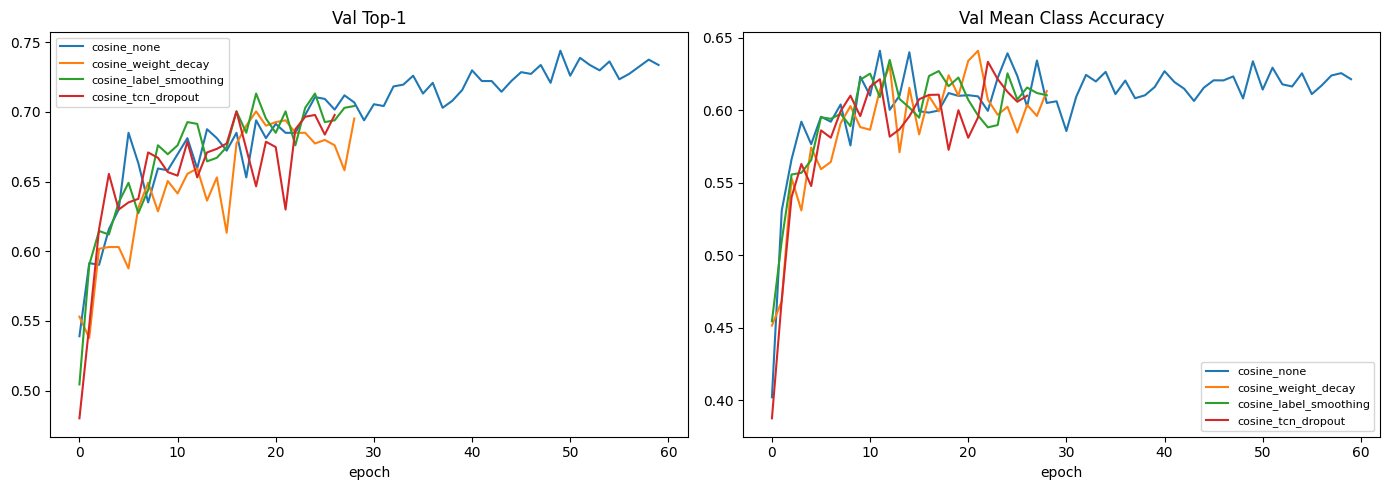

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, history in all_histories.items():
    axes[0].plot(history["val_top1"], label=name)
    axes[1].plot(history["val_mca"], label=name)
axes[0].set_title("Val Top-1"); axes[0].legend(fontsize=8)
axes[1].set_title("Val Mean Class Accuracy"); axes[1].legend(fontsize=8)
for ax in axes:
    ax.set_xlabel("epoch")
plt.tight_layout()
plt.savefig(os.path.join(OUT_ROOT, "cosine_ablation_curves.png"), dpi=200)
plt.show()


---

Check `cosine_tcn_dropout` first - if it now genuinely beats `cosine_none` (unlike the StepLR ablation where dropout hurt), that confirms dropout's effect really does depend on how long the model gets to train, not a fixed universal answer. Check `best_epoch` for every config too - if they're all landing well before epoch 60, patience=10 is doing its job; if any still ride the full budget, that config likely still needs even earlier stopping or more regularization, not more epochs.